# CROPSENSE PROJECT



## 1. Librairies

This project needs libraries in order to work.
You will may need to install them by using `pip install tifffile imagecodecs numpy pandas pymongo matplotlib opencv-python --user` on your Terminal (type cmd on Windows)

In [37]:
import os
import shutil
import re
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tifffile as tiff
from datetime import datetime
from pymongo import MongoClient
import gridfs
from scipy.interpolate import make_interp_spline

## 2. Setup and annex functions

### 2.1 Setup

In [2]:
PATH_INBOX = "C:/CROPSENSE/INBOX"          # Inbox folder (Camera software output)
PATH_DATA_ROOT = "C:/CROPSENSE/CROPSENSE_DATA" # Hierarchical final storage
PATH_EXPORT = "C:/CROPSENSE/EXPORTED_FROM_DB" # Path where exported data from database will be stored
CSV_LOG_PATH = "./experience_log.csv"      # Ground Truth tracking file

# MongoDB Connection (Auto-switch Local/Server)
URIS_TO_TRY = ['localhost', '172.20.10.8'] # Add your server IPs here
DB_NAME = 'cropsense_db'
COLLECTION_NAME = 'capture_events'

# Define SILIOS Wavelengths mapping for easier access
SILIOS_WAVELENGTHS = {
    0: "410nm", 1: "463nm", 2: "500nm", 3: "557nm", 4: "605nm",
    5: "666nm", 6: "693nm", 7: "756nm", 8: "807nm", 9: "869nm"
}

# Define the demosaicing pattern (Same as in your pipeline)
TOUCAN_PATTERN = {
    0: [(0,3), (2,1)], 1: [(0,1), (2,3)], 2: [(2,0)], 3: [(0,0), (2,2)],
    4: [(1,2)], 5: [(3,0)], 6: [(1,0)], 7: [(1,3), (3,1)],
    8: [(1,1), (3,3)], 9: [(3,2)]
}

# SILIOS TOUCAN Demosaicing Matrix (Fixed Pattern)
# Source: TOUCAN Matrix Filter arrangement V1.0
TOUCAN_PATTERN = {
    0: [(0,3), (2,1)], 1: [(0,1), (2,3)], 2: [(2,0)], 3: [(0,0), (2,2)],
    4: [(1,2)], 5: [(3,0)], 6: [(1,0)], 7: [(1,3), (3,1)],
    8: [(1,1), (3,3)], 9: [(3,2)]
}

### 2.2 Functions

#### 2.2.1 `get_mongo_client()`
This utility function implements a robust failover connection strategy for the database. It iterates through a predefined list of URI strings (typically `localhost` and the remote server IP) and attempts to establish a connection with a short timeout. It validates the connection by requesting server information; if successful, it returns the active MongoDB client object, ensuring the pipeline can operate seamlessly in both standalone and networked environments.

In [3]:
def get_mongo_client():
    """Attempts to connect to MongoDB using the provided list of URIs."""
    for uri in URIS_TO_TRY:
        print(f"Attempt to connect to MongoDB on {uri}")
        try:
            client = MongoClient(uri, 27017, serverSelectionTimeoutMS=2000)
            client.server_info() # Force connection check
            print(f"✅ Connected to MongoDB on {uri}")
            return client
        except:
            continue
    print("❌ Critical Error: No database accessible.")
    return None

#### 2.2.2 `parse_colorshades_manifest(txt_filepath)`
Designed to extract technical and scientific metadata, this function parses the auxiliary text files (`.txt`) generated by the Color Shades acquisition software. It reads the file content line by line to identify key parameters such as the camera serial number (Camera SN) and exposure time. Crucially, it also retrieves the calibrated filter wavelengths and channel normalization coefficients, ensuring that the subsequent spectral reconstruction adheres strictly to the specific radiometric calibration of the sensor.

In [4]:
def parse_colorshades_manifest(txt_filepath):
    """
    Parses the .txt manifest generated by Color Shades to extract technical metadata
    including real wavelengths and normalization coefficients.
    """
    meta = {
        "camera_sn": "Unknown", 
        "exposure": 1.0, 
        "wavelengths": [],    
        "coefficients": []    
    }
    
    if not os.path.exists(txt_filepath):
        return meta

    try:
        with open(txt_filepath, 'r') as f:
            content = f.readlines()
            
        for line in content:
            # Serial Number
            if "Camera SN" in line:
                meta["camera_sn"] = line.split(":")[-1].strip()
            
            # Exposure (remove " ms" unit)
            if "Exposure" in line:
                val = line.split(":")[-1].strip().replace(" ms", "")
                try: meta["exposure"] = float(val)
                except: pass
                
            # Real Wavelengths (e.g. 411, 463...)
            if "Filter's centering (nm)" in line:
                raw_vals = line.split(":")[-1].strip().split()
                meta["wavelengths"] = [int(x) for x in raw_vals]
                
            # Channel Coefficients
            if "Coefficients channel normalizer" in line:
                raw_vals = line.split(":")[-1].strip().split()
                meta["coefficients"] = [float(x) for x in raw_vals]
                
    except Exception as e:
        print(f"⚠️ Error reading manifest {os.path.basename(txt_filepath)}: {e}")
        
    return meta

#### 2.2.3 `organize_incoming_files()` 
This function acts as the ingestion engine of the pipeline. It scans the "`INBOX`" directory for raw files and uses Regular Expressions (Regex) to parse filenames, extracting the Plant ID and determining the sensor type (Spectral or Thermal). Based on the file creation timestamp and the extracted identifiers, it dynamically creates a hierarchical directory structure (`Date`/`PlantID`/`SensorType`) and moves the files from the temporary inbox to this permanent storage, effectively automating the data sorting process and filtering out irrelevant files like screenshots.

In [5]:
def organize_incoming_files():
    """
    Sorts files from INBOX into the hierarchy: DATA_ROOT / Date / Plant_ID / Sensor_Type
    Implements specific logic for prefixes 'Spectral', 'Multispectral', 'Thermal'.
    """
    print("\n--- 1. Sorting incoming files (INBOX) ---")
    if not os.path.exists(PATH_INBOX): 
        print(f"⚠️ Inbox directory not found: {PATH_INBOX}")
        return

    count = 0
    # Reserved keywords that cannot be Plant IDs
    RESERVED_KEYWORDS = ["SPECTRAL", "MULTISPECTRAL", "THERMAL"]

    for filename in os.listdir(PATH_INBOX):
        file_path = os.path.join(PATH_INBOX, filename)
        if os.path.isdir(file_path): continue

        # Init variables
        plant_id = "Unassigned"
        sensor_type = "Unclassified"
        filename_clean = filename.strip()
        
        # --- RULE 1: EXPLICIT PREFIX DETECTION ---
        # Check if file starts with specific keywords followed by a separator (e.g., "_")
        # Regex looks for: (Spectral|Thermal) _ (PotentialID) _ (Rest)
        match_explicit = re.match(r"^(Spectral|Multispectral|Thermal)_([a-zA-Z0-9]+)_(.*)", filename_clean, re.IGNORECASE)
        
        if match_explicit:
            type_str = match_explicit.group(1).upper()
            candidate_id = match_explicit.group(2)
            
            # 1.1 Determine Sensor Type
            if "THERMAL" in type_str:
                sensor_type = "Thermal"
            else:
                sensor_type = "Spectral"
                
            # 1.2 Validate Plant ID
            # Rule: Must not be a reserved word AND must start with a letter
            if candidate_id.upper() not in RESERVED_KEYWORDS and candidate_id[0].isalpha():
                plant_id = candidate_id
            else:
                plant_id = "Unassigned"
                
        else:
            # --- RULE 2: FALLBACK PATTERN DETECTION ---
            # If no explicit prefix, try to guess based on file structure
            
            # Case A: Thermal (Starts with digits like "00-10-12...")
            # Also checks for thermal keywords if the pattern matches
            if re.match(r"^(\d{2}-\d{2}-\d{2}-\d{3})", filename_clean):
                sensor_type = "Thermal"
                print(f"   [Ingestion] Pattern Detection used: Thermal Digit Pattern detected for {filename}")
                plant_id = "Unassigned" # Thermal files usually don't have the ID in the name here
                 
            # Case B: Spectral (Contains Date_Time pattern OR ends with specific extensions)
            elif re.search(r"_\d{8}_\d{6}_", filename_clean) or filename_clean.lower().endswith(('_raw.tiff', '.txt')):
                sensor_type = "Spectral"
            print(f"   [Ingestion] Pattern Detection used: Spectral Date/Time Pattern detected for {filename}")
                
                # Try to extract Plant ID from the start of the file
                # Split by first underscore
            parts = filename_clean.split('_')
            if len(parts) > 1:
                    candidate = parts[0]
                    # Same validation rules
                    if candidate.upper() not in RESERVED_KEYWORDS and candidate[0].isalpha():
                        plant_id = candidate
                    else:
                        plant_id = "Unassigned"

        print(f"   [Ingestion] File: {filename} -> Detected Type: {sensor_type}, Plant: {plant_id}")

        # --- PROCESSING & MOVING ---
        
        # Filter: Delete Thermal Screenshots
        if sensor_type == "Thermal" and "screenshot" in filename_clean.lower():
            try:
                os.remove(file_path)
                print(f"🗑️ Deleted screenshot: {filename}")
            except Exception as e:
                print(f"⚠️ Could not delete {filename}: {e}")
            continue
            
        # Move Valid Files
        if sensor_type != "Unclassified":
            try:
                timestamp = os.path.getmtime(file_path)
                date_folder = datetime.fromtimestamp(timestamp).strftime('%Y-%m-%d')
                
                # Target: DATA / Date / PlantID / SensorType
                target_dir = os.path.join(PATH_DATA_ROOT, date_folder, plant_id, sensor_type)
                os.makedirs(target_dir, exist_ok=True)
                
                target_path = os.path.join(target_dir, filename)
                if not os.path.exists(target_path):
                    shutil.move(file_path, target_path)
                    count += 1
                    print(f"📦 Moved: {filename} -> {plant_id}/{sensor_type}")
                else:
                    print(f"ℹ️ Skipped (Duplicate): {filename}")
            except Exception as e:
                print(f"❌ Error moving {filename}: {e}")
        else:
            print(f"⚠️ Skipped Unclassified file: {filename}")

    print(f"   -> {count} files successfully organized.")

#### 2.2.4 `process_spectral_image(filepath, manifest_meta)`
This function executes the core signal processing for multispectral data by reading raw `TIFF` images and applying a demosaicing algorithm based on the SILIOS TOUCAN 4x4 filter pattern to reconstruct a 10-band spectral cube. Crucially, it applies radiometric correction by normalizing the raw pixel intensity of each band using specific coefficients retrieved from the sensor's manifest file. Finally, it extracts features by generating an intensity histogram (`256 bins`) for each corrected wavelength (dynamically named based on the manifest, e.g., 411nm), packaging these analytics alongside the correction factors into a dictionary for database storage.

In [6]:
def process_spectral_image(filepath, manifest_meta):
    img_data = tiff.imread(filepath)
    h, w = img_data.shape
    print(f"   [Processing] Loaded Raw TIFF. Dimensions: {w}x{h} pixels.")
    new_h, new_w = h // 4, w // 4
    
    # Retrieve dynamic info from the text file
    # If the text file was missing, use default values
    real_wavelengths = manifest_meta.get("wavelengths")
    if not real_wavelengths or len(real_wavelengths) != 10:
        real_wavelengths = [411, 463, 500, 557, 606, 667, 694, 756, 808, 870] # Fallback
        
    coeffs = manifest_meta.get("coefficients")
    if not coeffs or len(coeffs) != 10:
        coeffs = [1.0] * 10 # No correction if file is missing
        
    cube = np.zeros((10, new_h, new_w), dtype=np.float32)
    analytics = {}
    print(f"   [Processing] Applied Normalization Coefficients: {coeffs}")
    
    for band_idx, coords in TOUCAN_PATTERN.items():
        # 1. Reconstruction (Demosaicing)
        stack = [img_data[r::4, c::4][:new_h, :new_w] for r, c in coords]
        raw_band = np.mean(stack, axis=0)
        
        # 2. Radiometric Correction (Applying the coefficient)
        # This is the crucial step: normalizing the intensity
        corrected_band = raw_band * coeffs[band_idx]
        
        # Store in the cube
        cube[band_idx] = corrected_band

        print(f"   [Processing] Signal Stats -> Min: {np.min(cube):.2f}, Max: {np.max(cube):.2f}, Mean: {np.mean(cube):.2f}")
        
        # 3. Histogram Calculation on the CORRECTED band
        # Use the real name (e.g., "411nm" not "410nm")
        band_name = f"{real_wavelengths[band_idx]}nm"
        
        # Round for the histogram because coefficients create decimals
        hist, _ = np.histogram(corrected_band.astype(np.uint16), bins=256)
        
        analytics[band_name] = {
            "histogram": hist.tolist(),
            "correction_factor": coeffs[band_idx] # Store the factor used
        }
        
    return {
        "camera_model": "SILIOS TOUCAN",
        "camera_sn": manifest_meta.get("camera_sn", "Unknown"),
        "exposure_ms": manifest_meta.get("exposure"),
        "analytics": analytics
    }

#### 2.2.5 `find_thermal_cluster(spectral_path, tolerance=120)` 
To achieve sensor fusion, this function implements a temporal reconciliation algorithm. Using the timestamp of a processed spectral image as a reference anchor, it recursively scans the daily directory structure to locate 'Thermal' subfolders. It identifies files created within a defined tolerance window (e.g., ±300 seconds) and aggregates the four specific output files generated by the Workswell camera—Visual RGB, Radiometric JPEG, Raw Thermal TIFF, and CWSI TIFF—into a unified logical cluster, thereby linking asynchronous captures into a single event.

In [7]:
def find_thermal_cluster(spectral_path, plant_id, tolerance=300):
    """
    Finds the cluster of 4 Workswell thermal files corresponding to the spectral image timestamp, according to their ID.
    Searches in all 'Thermal' subfolders for the same date.
    """
    matches = {}
    spec_time = datetime.fromtimestamp(os.path.getmtime(spectral_path))
    
    # 1. Construct the specific target path
    # Structure: DATA / Date / PlantID / Spectral  --> We want DATA / Date / PlantID / Thermal
    spectral_folder = os.path.dirname(spectral_path)    # .../PlantID/Spectral
    plant_root = os.path.dirname(spectral_folder)       # .../PlantID
    target_thermal_dir = os.path.join(plant_root, "Thermal")
    
    # 2. Immediate exit if the folder doesn't exist for THIS plant
    if not os.path.exists(target_thermal_dir): 
        return matches

    # 3. Scan ONLY this specific directory
    for f in os.listdir(target_thermal_dir):
        f_path = os.path.join(target_thermal_dir, f)
        
        # Skip directories
        if os.path.isdir(f_path): continue
        
        # Check time
        therm_time = datetime.fromtimestamp(os.path.getmtime(f_path))
        
        if abs((spec_time - therm_time).total_seconds()) <= tolerance:
            if "visible" in f: matches["visual_rgb"] = f_path
            elif "radiometric" in f: matches["radiometric_jpg"] = f_path
            elif "thermo" in f: matches["raw_thermal_tiff"] = f_path
            elif "cwsi" in f: matches["cwsi_tiff"] = f_path
                    
    return matches

#### 2.2.6 `save_gridfs_file(fs, file_id, folder, default_name)`
An helper function to save a single file from GridFS.
It is used for example on `batch_export_all()`

In [8]:
def save_gridfs_file(fs, file_id, folder, default_name):
    """Helper function to save a single file from GridFS"""
    try:
        grid_out = fs.get(file_id)
        
        # Use the real filename if available in GridFS metadata
        if grid_out.filename:
            final_name = grid_out.filename
        else:
            final_name = default_name
            
        output_path = os.path.join(folder, final_name)
        
        # Skip if already exists
        if os.path.exists(output_path):
            return

        with open(output_path, 'wb') as f:
            f.write(grid_out.read())
            
    except Exception as e:
        print(f"      -> Failed to save file {file_id}: {e}")

#### 2.2.7 `process_independent_thermal(date_folder_path, db_collection, fs)`

This function acts as a comprehensive safety mechanism designed to ingest thermal datasets that were not temporally synchronized with spectral images during the main pipeline execution. By performing a secondary scan of the Thermal directories, it systematically identifies and groups isolated Workswell camera outputs—combining the Visible, Radiometric, Raw TIFF, and CWSI files into coherent acquisition events based on their shared timestamps. To maintain database integrity, the function performs a rigorous deduplication check against MongoDB, ensuring that only truly new data is processed. These independent events are then archived with a specific schema where the multispectral field is explicitly set to null, allowing researchers to easily query and distinguish standalone thermal experiments from multi-sensor data within the global dataset.

In [9]:
def process_independent_thermal(date_folder_path, db_collection, fs):
    """
    Scans for thermal files that were NOT linked to a spectral event and uploads them.
    No specific tag is added to the database; the spectral field will simply be Null.
    
    Args:
        date_folder_path (str): Path to the Date folder (e.g., .../2025-12-10/)
        db_collection: MongoDB collection object
        fs: GridFS object
    """
    print(f"\n🔄 [Independent Thermal] Scanning for standalone thermal data in {os.path.basename(date_folder_path)}...")
    
    count_new = 0
    
    # 1. Walk through all folders in this Date
    for root, dirs, files in os.walk(date_folder_path):
        folder_name = os.path.basename(root)
        
        # We only care about "Thermal" folders
        if folder_name != "Thermal":
            continue
            
        # Deduce Plant ID from parent folder (e.g. .../P01/Thermal -> P01)
        plant_id = os.path.basename(os.path.dirname(root))
        
        # 2. Group files by 'Shot' (Timestamp prefix)
        # Workswell files look like: "14-20-00-123-thermo.tiff"
        shots = {}
        
        for f in files:
            # Simple regex to capture the HH-MM-SS-mmm prefix
            match = re.match(r"^(\d{2}-\d{2}-\d{2}-\d{3})", f)
            if match:
                prefix = match.group(1)
                if prefix not in shots: shots[prefix] = {}
                
                full_path = os.path.join(root, f)
                
                # Assign type
                if "visible" in f: shots[prefix]["visual_rgb"] = full_path
                elif "radiometric" in f: shots[prefix]["radiometric_jpg"] = full_path
                elif "thermo" in f: shots[prefix]["raw_thermal_tiff"] = full_path
                elif "cwsi" in f: shots[prefix]["cwsi_tiff"] = full_path

        # 3. Process each shot
        for prefix, file_dict in shots.items():
            
            # CHECK: Does this thermal data already exist in DB?
            # We look for the filename in the 'sensor_thermal' section to avoid duplicates.
            if "raw_thermal_tiff" in file_dict:
                ref_filename = os.path.basename(file_dict["raw_thermal_tiff"])
                exists = db_collection.find_one({"sensor_thermal.original_filename": ref_filename})
                
                if exists:
                    # Already processed (either via Spectral Fusion or previously imported) -> Skip
                    continue
            
            # 4. If not in DB, it's a new Independent Event
            stored_files_ids = {}
            
            # Upload files to GridFS
            for f_type, f_path in file_dict.items():
                try:
                    with open(f_path, 'rb') as f_in:
                        # We upload to GridFS
                        fid = fs.put(f_in, filename=os.path.basename(f_path), content_type="image/tiff")
                        stored_files_ids[f_type] = fid
                except Exception as e:
                    print(f"   ⚠️ Error uploading {f_path}: {e}")

            # Create Database Document
            try:
                # Reconstruct timestamp from filename (HH-MM-SS-mmm) and Folder Date
                time_parts = prefix.split("-") # ['14', '20', '00', '123']
                date_str = os.path.basename(date_folder_path) # '2025-12-10'
                
                # Format: YYYY-MM-DD HH:MM:SS
                timestamp_str = f"{date_str} {time_parts[0]}:{time_parts[1]}:{time_parts[2]}"
                
                event_doc = {
                    "context": {
                        "plant_id": plant_id,
                        "timestamp": timestamp_str
                        # No 'mode' tag added here, keeping it clean.
                    },
                    "sensor_multispectral": None, # Explicitly Empty
                    "sensor_thermal": {
                        "camera_model": "WORKSWELL WIRIS AGRO R",
                        "original_filename": os.path.basename(file_dict.get("raw_thermal_tiff", "unknown")),
                        "files": stored_files_ids,
                        "detected_count": len(stored_files_ids)
                    }
                }
                
                db_collection.insert_one(event_doc)
                print(f"   ✅ Saved Thermal Event (No Spectral): {plant_id} @ {time_parts[0]}:{time_parts[1]}")
                count_new += 1
                
            except Exception as e:
                print(f"   ❌ Error saving doc: {e}")

    print(f"   -> Added {count_new} new independent thermal events.")

## 3. Main functions

#### 3.1 `run_pipeline()`
This is the main orchestrator function that executes the full ETL (Extract, Transform, Load) workflow. It sequentially triggers the file organization, establishes the database connection, and iterates through the structured dataset. For every valid spectral image found, it coordinates the processing (via `process_spectral_image`), the fusion (via `find_thermal_cluster`), and the construction of the final JSON document. Finally, it handles the upload of binary files to MongoDB's GridFS and the insertion of the structured document into the collection.

#### ⚠️ RUN IT ONLY WHEN YOUR DATA IS CLEAN ⚠️

In [10]:
def run_pipeline():
    # A. Ingestion (Organization)
    organize_incoming_files()
    
    # B. Database Connection
    client = get_mongo_client()
    if not client: return
    
    db = client[DB_NAME]
    fs = gridfs.GridFS(db)
    coll = db[COLLECTION_NAME]

    print("\n--- 2. Scientific Processing ---")
    
    # Iterate through organized data
    for root, dirs, files in os.walk(PATH_DATA_ROOT):
        # We drive the process using Spectral folders
        if os.path.basename(root) != "Spectral": continue
        
        # 1. Search for Manifest (.txt)
        manifest_meta = {}
        txt_files = [f for f in files if f.endswith(".txt")]
        if txt_files:
            manifest_meta = parse_colorshades_manifest(os.path.join(root, txt_files[0]))
            print(f"📄 [Manifest] {txt_files[0]} Loaded metadata -> SN: {manifest_meta.get('camera_sn')}, Exp: {manifest_meta.get('exposure')}ms")

        # 2. Process Images
        for file in files:
            if not file.endswith("_raw.tiff"): continue
            
            # Anti-Duplicate Check
            if coll.count_documents({"sensor_multispectral.filename": file}) > 0:
                continue

            print(f"⚙️ Processing: {file}")
            filepath = os.path.join(root, file)
            
            try:
                # Identification from folder structure
                plant_id = os.path.basename(os.path.dirname(root)) 
                timestamp = datetime.fromtimestamp(os.path.getmtime(filepath))
                
                # Processing (Spectral)
                # Note: Uses 'manifest_meta' to apply coefficients if implemented
                spec_data = process_spectral_image(filepath, manifest_meta)
                
                # Fusion (Thermal)
                thermal_files = find_thermal_cluster(filepath, plant_id=plant_id)
                
                # --- AJOUT DU PRINT DE DÉBOGAGE ICI ---
                if thermal_files:
                    # On récupère juste le nom des fichiers pour que ce soit lisible
                    t_names = [os.path.basename(p) for p in thermal_files.values()]
                    print(f"   🔗 [Fusion] Thermal files associated : {t_names}")
                else:
                    print("   ⚠️ [Fusion] Aucun fichier thermique correspondant trouvé (hors délai).")
                    
                print(f"   [Fusion] Thermal files found: {list(thermal_files.keys())}")
                thermal_data = {
                    "camera_model": "WORKSWELL WIRIS AGRO R",
                    "files": {},
                    "detected_count": len(thermal_files)
                }

                # Auto-Tagging Control Samples
                tags = []
                if plant_id in ['P02', 'P50', 'Plant_2', 'Plant_50']: 
                    tags.append("control_sample")

                print(f"   [Metadata] Assigned Tags: {tags}")

                # Document Assembly
                doc = {
                    "context": {
                        "plant_id": plant_id,
                        "timestamp": timestamp,
                        "session": "Morning" if timestamp.hour < 13 else "Evening",
                        "environment": "Laboratory"
                    },
                    "sensor_multispectral": {
                        "filename": file,
                        "meta": spec_data,
                        "raw_file_id": None
                    },
                    "sensor_thermal": thermal_data,
                    "tags": tags
                }
                # C. Upload to Database
                print(f"   [Storage] Uploading Spectral binary file ({os.path.getsize(filepath)} bytes) to GridFS...")
                
                # 1. Upload Spectral Image
                with open(filepath, 'rb') as f:
                    doc['sensor_multispectral']['raw_file_id'] = fs.put(f, filename=file)
                
                # 2. Upload Thermal Files (if any)
                for key, t_path in thermal_files.items():
                    with open(t_path, 'rb') as f:
                        file_id = fs.put(f, filename=os.path.basename(t_path))
                        doc['sensor_thermal']['files'][key] = file_id

                # 3. Save Metadata Document
                coll.insert_one(doc)
                print(f"✅ [Success] Event recorded for {plant_id} at {timestamp}. (DB ID: {doc['_id']})")

            except Exception as e:
                print(f"   ❌ Error processing {file}: {e}")
    print("\n--- 3. Independent Thermal Scan ---")
    for date_folder in os.listdir(PATH_DATA_ROOT):
        full_date_path = os.path.join(PATH_DATA_ROOT, date_folder)
        if os.path.isdir(full_date_path):
            process_independent_thermal(full_date_path, coll, fs)
            
    print("\n✅ Pipeline execution complete.")

### 3.2 `rename_batch_prefix(folder_path, old_prefix, new_prefix)`
This function batch renames all files in a folder that start with an old prefix, replacing that start with a new prefix.
Useful when the files saved are prenamed by the camera or the sofware output, and you want to change the name of all the file you just used, or you want to solve a mistake.

In [11]:
def rename_batch_prefix(folder_path, old_prefix, new_prefix):
    """
    Batch renames all files in a folder that start with 'old_prefix',
    replacing that start with 'new_prefix'.
    
    Example: 
    rename_batch_prefix("C:/INBOX", "hbda", "PLANT1")
    will transform "hbda.0001.tiff" into "PLANT1.0001.tiff"
    """
    
    # 1. Folder verification
    if not os.path.exists(folder_path):
        print(f"❌ Folder does not exist: {folder_path}")
        return

    print(f"🔄 Renaming in progress in {folder_path}...")
    print(f"   Replacing '{old_prefix}' with '{new_prefix}'")
    
    count = 0
    errors = 0

    # 2. Iterate through files
    for filename in os.listdir(folder_path):
        # Process only files starting with the old prefix
        if filename.startswith(old_prefix):
            
            # Construct the new filename
            # Cut the "old_prefix" part and paste "new_prefix" at the start
            suffix = filename[len(old_prefix):] # The rest of the name (e.g., ".0001.tiff")
            new_filename = new_prefix + suffix
            
            old_path = os.path.join(folder_path, filename)
            new_path = os.path.join(folder_path, new_filename)
            
            try:
                # Safety check: do not overwrite if the file already exists
                if os.path.exists(new_path):
                    print(f"⚠️ Skipped (Already exists): {new_filename}")
                    errors += 1
                    continue
                
                # Actual renaming
                os.rename(old_path, new_path)
                print(f"✅ {filename} -> {new_filename}")
                count += 1
                
            except Exception as e:
                print(f"❌ Error on {filename}: {e}")
                errors += 1

    print(f"\n--- Finished: {count} files renamed ({errors} errors) ---")

### 3.3 `export_file_from_db(output_folder, plant_id, sensor_type, thermal_file_type, mongo_uri, db_name)`
This function retrieves a multispectral file from a MongoDB database and saves it to a specified output folder on the local disk. By default, it fetches the most recent image recorded in the database; however, if a specific `plant_id` is provided, the search is filtered to retrieve the last image associated with that plant. The connection is established using the provided mongo_uri (defaulting to '`localhost`') and db_name. If `sensor_type` equals to `spectral`, `thermal_file_type` has no use. However, if `sensor_type` equals to `thermal`, `thermal_file_type` allows to choose between `visual_rgb`, `radiometric.jpg`, `raw_thermal_tiff`, and `cwsi_tiff`. Upon completion, the function returns the absolute path of the saved file, or `None` if the operation fails.

In [12]:
def export_file_from_db(output_folder, plant_id=None, sensor_type='spectral', thermal_file_type='radiometric_jpg', mongo_uri='localhost', db_name='cropsense_db'):
    """
    Retrieves a file (Spectral OR Thermal) from MongoDB and saves it to disk.
    
    Parameters:
    - output_folder (str): Destination folder.
    - plant_id (str, optional): ID of the plant (e.g., "P01"). If None, takes the latest event.
    - sensor_type (str): 'spectral' OR 'thermal'.
    - thermal_file_type (str): Only if sensor_type='thermal'. 
                               Options: 'visual_rgb', 'radiometric_jpg', 'raw_thermal_tiff', 'cwsi_tiff'.
    """
    
    # 1. Connect to DB
    try:
        client = MongoClient(mongo_uri, 27017, serverSelectionTimeoutMS=2000)
        db = client[db_name]
        fs = gridfs.GridFS(db)
        coll = db['capture_events']
        client.server_info()
    except Exception as e:
        print(f"❌ Connection Error: {e}")
        return None

    # 2. Find Event
    query = {}
    if plant_id:
        query["context.plant_id"] = plant_id
        print(f"🔍 Searching last event for plant: {plant_id}...")
    else:
        print("🔍 Searching for the very last event recorded...")

    event = coll.find_one(query, sort=[("context.timestamp", -1)])
    if not event:
        print("⚠️ No event found.")
        return None

    # 3. Identify File ID based on request
    file_id = None
    original_filename = "unknown_file"

    try:
        if sensor_type == 'spectral':
            # Get the main TIFF file
            data_node = event.get('sensor_multispectral', {})
            file_id = data_node.get('raw_file_id')
            original_filename = data_node.get('filename', 'spectral.tif')
            
        elif sensor_type == 'thermal':
            # Get one of the 4 thermal files
            files_node = event.get('sensor_thermal', {}).get('files', {})
            
            # Map the user request to the database keys
            # Database keys are: visual_rgb_id, radiometric_jpg_id, etc.
            # We construct the key dynamically:
            db_key = f"{thermal_file_type}_id" # e.g. "radiometric_jpg_id"
            
            file_id = files_node.get(db_key)
            
            # We try to reconstruct a name (since it wasn't explicitly stored in the simplified node)
            # But GridFS knows the name! We will get it later.
            original_filename = f"thermal_{thermal_file_type}.img" 

        # 4. Download and Save
        if not file_id:
            print(f"⚠️ No file found for sensor '{sensor_type}' (Type: {thermal_file_type}) in this event.")
            return None

        if not os.path.exists(output_folder):
            os.makedirs(output_folder)

        # Retrieve from GridFS
        grid_out = fs.get(file_id)
        data = grid_out.read()
        
        # Use the real filename stored in GridFS if possible
        if grid_out.filename:
            original_filename = grid_out.filename
            
        output_path = os.path.join(output_folder, original_filename)
        
        with open(output_path, 'wb') as f:
            f.write(data)
            
        print(f"✅ File saved: {output_path}")
        print(f"   (Source: {sensor_type} | Date: {event['context']['timestamp']})")
        return output_path

    except Exception as e:
        print(f"❌ Error during extraction: {e}")
        return None

### 3.4 `batch_export_all()`
This function is a mass extraction tool designed to reconstruct your entire physical dataset from the MongoDB database. It begins by establishing a connection to the server and retrieving all recorded event documents, then iterates through each entry to extract contextual metadata (plant identifier and date). 

Using this information, it dynamically recreates a structured folder hierarchy on your hard drive (e.g., `EXPORT/P01/2025-11-25`) and queries the GridFS system to download and write the original binary files (spectral TIFF and thermal images) back into their respective folders, thereby ensuring a comprehensive backup or data transfer to a standard file system.

In [13]:
def batch_export_all():
    print(f"🚀 Starting Batch Export to: {EXPORT_ROOT}")
    
    # 1. Connection
    try:
        client = MongoClient(MONGO_URI, 27017, serverSelectionTimeoutMS=2000)
        db = client[DB_NAME]
        fs = gridfs.GridFS(db)
        coll = db['capture_events']
        client.server_info()
    except Exception as e:
        print(f"❌ Connection Error: {e}")
        return

    # 2. Get ALL events
    # You can add a filter here, e.g., {"context.plant_id": "P01"}
    cursor = coll.find({}) 
    total_docs = coll.count_documents({})
    
    print(f"📦 Found {total_docs} events to process...")

    count = 0
    for doc in cursor:
        try:
            # 3. Context Info
            context = doc.get('context', {})
            plant_id = context.get('plant_id', 'Unknown')
            # Safe timestamp handling
            ts = context.get('timestamp')
            if isinstance(ts, str): # If stored as string
                date_str = ts[:10] # YYYY-MM-DD
            elif isinstance(ts, datetime): # If stored as Date object
                date_str = ts.strftime('%Y-%m-%d')
            else:
                date_str = "NoDate"

            # 4. Create Target Folder
            # Structure: EXPORT / PlantID / Date
            target_folder = os.path.join(EXPORT_ROOT, plant_id, date_str)
            if not os.path.exists(target_folder):
                os.makedirs(target_folder)

            # 5. Export Spectral File
            spec_node = doc.get('sensor_multispectral', {})
            spec_id = spec_node.get('raw_file_id')
            if spec_id:
                filename = spec_node.get('filename', f"spectral_{plant_id}.tif")
                save_gridfs_file(fs, spec_id, target_folder, filename)

            # 6. Export Thermal Files
            therm_node = doc.get('sensor_thermal', {}).get('files', {})
            for file_type, file_id in therm_node.items():
                # file_type is like "radiometric_jpg_id"
                # We construct a name if the original isn't stored, or get it from GridFS
                filename = f"thermal_{file_type}.img" 
                save_gridfs_file(fs, file_id, target_folder, filename)

            count += 1
            print(f"   [{count}/{total_docs}] Processed {plant_id} ({date_str})")

        except Exception as e:
            print(f"   ❌ Error processing doc {doc.get('_id')}: {e}")

    print("\n✅ Batch Export Completed.")

### 3.5 `export_recent_files(output_folder, limit, plant_id, sensor_type, thermal_file_type, mongo_uri, db_name)`

This function retrieves the most recent batch of images from the database and saves them to the specified `output_folder`. The number of retrieved files is controlled by the limit parameter (defaulting to 5), and the query can be optionally filtered by a specific `plant_id` or left open to include all plants. The function requires defining the `sensor_type` as either '`spectral`' or '`thermal`'; if '`thermal`' is selected, the specific file format (such as '`visual_rgb`' or '`radiometric_jpg`') must be designated using the `thermal_file_type` argument.

In [14]:
def export_recent_files(output_folder, limit=5, plant_id=None, sensor_type='spectral', thermal_file_type='radiometric_jpg', mongo_uri='localhost', db_name='cropsense_db'):
    """
    Retrieves the last 'n' images recorded in the database.
    
    Parameters:
    - output_folder (str): Folder where files will be saved.
    - limit (int): Number of files to retrieve (default 5).
    - plant_id (str, optional): Filter by plant (e.g., "P01"). If None, takes all plants.
    - sensor_type (str): 'spectral' OR 'thermal'.
    - thermal_file_type (str): If thermal, which file? ('visual_rgb', 'radiometric_jpg', etc.)
    """
    
    # 1. Connection
    try:
        client = MongoClient(mongo_uri, 27017, serverSelectionTimeoutMS=2000)
        db = client[db_name]
        fs = gridfs.GridFS(db)
        coll = db['capture_events']
        client.server_info()
    except Exception as e:
        print(f"❌ Connection Error: {e}")
        return

    # 2. Query Configuration
    query = {}
    if plant_id:
        query["context.plant_id"] = plant_id
        print(f"🔍 Searching for the last {limit} images for plant: {plant_id}...")
    else:
        print(f"🔍 Searching for the last {limit} images (all plants)...")

    # 3. Retrieve cursor (Sorted by date DESC)
    # .limit(limit) restricts the number of results
    cursor = coll.find(query).sort("context.timestamp", -1).limit(limit)
    
    count = 0
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # 4. Loop through results
    for event in cursor:
        try:
            # -- Same logic as the single function to find the ID --
            file_id = None
            filename_prefix = ""

            if sensor_type == 'spectral':
                data_node = event.get('sensor_multispectral', {})
                file_id = data_node.get('raw_file_id')
                # We add the timestamp to the name to avoid duplicates if filenames are identical
                ts_str = event['context']['timestamp'].strftime("%H%M%S")
                original_name = data_node.get('filename', 'spec.tif')
                
            elif sensor_type == 'thermal':
                files_node = event.get('sensor_thermal', {}).get('files', {})
                db_key = f"{thermal_file_type}_id"
                file_id = files_node.get(db_key)
                ts_str = event['context']['timestamp'].strftime("%H%M%S")
                original_name = f"thermal_{thermal_file_type}.img"

            # -- Download --
            if file_id:
                grid_out = fs.get(file_id)
                # If GridFS has the real name, use it, otherwise use the constructed one
                final_name = grid_out.filename if grid_out.filename else original_name
                
                # Security: To avoid overwriting, we can prefix with the plant ID
                p_id = event['context']['plant_id']
                save_name = f"{p_id}_{final_name}"
                
                output_path = os.path.join(output_folder, save_name)
                
                with open(output_path, 'wb') as f:
                    f.write(grid_out.read())
                
                print(f"   ✅ [{count+1}/{limit}] Saved: {save_name}")
                count += 1
            else:
                print(f"   ⚠️ Event found but no file for this sensor (Plant: {event['context']['plant_id']})")

        except Exception as e:
            print(f"   ❌ Error on a file: {e}")

    print(f"🚀 Completed. {count} files exported to {output_folder}")

### 3.6 `check_database_integrity(plant_id_to_check, mongo_uri, db_name)`

In [15]:
def check_database_integrity(plant_id_to_check, mongo_uri='localhost', db_name='cropsense_db'):
    """
    Diagnose function to verify if files for a specific plant are correctly stored in GridFS.
    
    Args:
        plant_id_to_check (str): The Plant ID to look for (e.g., "FirstTests", "PO1").
        mongo_uri (str): Address of the MongoDB server.
    """
    print(f"\n🔍 --- DIAGNOSIS FOR PLANT: {plant_id_to_check} ---")
    
    # 1. Connection
    try:
        client = MongoClient(mongo_uri, 27017, serverSelectionTimeoutMS=2000)
        db = client[db_name]
        fs = gridfs.GridFS(db)
        coll = db['capture_events']
        client.server_info() # Check connection
    except Exception as e:
        print(f"❌ Connection Failed: {e}")
        return

    # 2. General Stats
    total_files = db['fs.files'].count_documents({})
    print(f"📦 Total binary files in GridFS (All plants): {total_files}")

    # 3. Find the Document
    # We look for the most recent event for this plant
    event = coll.find_one({"context.plant_id": plant_id_to_check}, sort=[("context.timestamp", -1)])

    if not event:
        print(f"❌ No metadata document found for plant '{plant_id_to_check}'.")
        print("   -> Check if the Plant ID is correct (Case sensitive!).")
        return

    print(f"✅ Metadata document found (Date: {event['context']['timestamp']})")

    # 4. Check Spectral File
    print("\n   [Spectral Sensor]")
    spec_id = event.get('sensor_multispectral', {}).get('raw_file_id')
    if spec_id:
        if fs.exists(spec_id):
            file_meta = fs.get(spec_id)
            print(f"     ✅ RAW TIFF exists (Size: {file_meta.length / 1024 / 1024:.2f} MB)")
        else:
            print(f"     ❌ ERROR: File ID exists in document but file is missing in GridFS!")
    else:
        print("     ⚠️ No Spectral file linked.")

    # 5. Check Thermal Files
    print("\n   [Thermal Sensor]")
    thermal_files = event.get('sensor_thermal', {}).get('files', {})
    
    if not thermal_files:
        print("     ⚠️ No Thermal files linked (Empty list).")
    else:
        for file_type, file_id in thermal_files.items():
            if fs.exists(file_id):
                file_meta = fs.get(file_id)
                print(f"     ✅ {file_type}: OK (Size: {file_meta.length / 1024:.2f} KB)")
            else:
                print(f"     ❌ {file_type}: Missing body in GridFS (ID: {file_id})")

### 3.7 `show_spectral_channel(filepath, channel_index, wavelength)`

This visualization utility is designed to permit granular inspection of the multispectral data. It provides a flexible interface allowing users to query a specific spectral band either by its index (0-9) or its physical wavelength (e.g., '756nm'). The function automatically adapts to the input file format: for pre-processed spectral stacks (3D arrays), it extracts the corresponding slice, while for raw sensor mosaics (2D arrays), it executes an on-the-fly demosaicing process to reconstruct the specific band image based on the sensor's filter matrix. The resulting radiometric data is then rendered as a high-contrast color-mapped heatmap using Matplotlib, facilitating the visual assessment of pixel intensity distributions across the leaf surface.

In [16]:
def show_spectral_channel(filepath, channel_index=None, wavelength=None):
    """
    Displays a specific channel from a SILIOS multispectral TIFF file.
    
    Parameters:
    - filepath (str): Path to the .tiff file (Raw Mosaic or Stack).
    - channel_index (int): Index of the band (0 to 9).
    - wavelength (str/int): Wavelength to find (e.g., 557 or "557nm"). 
                            Overrides channel_index if provided.
    """
    
    # 1. Resolve Channel Index from Wavelength
    if wavelength is not None:
        # Clean up input (remove 'nm', convert to int)
        target = str(wavelength).replace("nm", "").strip()
        found = False
        for idx, name in SILIOS_WAVELENGTHS.items():
            if target in name:
                channel_index = idx
                found = True
                break
        if not found:
            print(f"❌ Wavelength '{wavelength}' not found. Available: {list(SILIOS_WAVELENGTHS.values())}")
            return

    if channel_index is None or not (0 <= channel_index <= 9):
        print(f"❌ Invalid channel index: {channel_index}. Must be between 0 and 9.")
        return

    # 2. Load Image
    try:
        img_data = tiff.imread(filepath)
    except Exception as e:
        print(f"❌ Error reading file: {e}")
        return

    # 3. Handle RAW Mosaic vs Stack
    band_image = None
    
    # Case A: Stack (3D Array -> 10, H, W)
    if img_data.ndim == 3 and img_data.shape[0] == 10:
        band_image = img_data[channel_index]
        mode = "Pre-processed Stack"

    # Case B: Raw Mosaic (2D Array -> H, W)
    elif img_data.ndim == 2:
        # Perform on-the-fly demosaicing for just ONE channel
        h, w = img_data.shape
        new_h, new_w = h // 4, w // 4
        
        coords = TOUCAN_PATTERN[channel_index]
        # Extract and average sub-pixels for this specific band
        stack = [img_data[r::4, c::4][:new_h, :new_w] for r, c in coords]
        band_image = np.mean(stack, axis=0)
        mode = "Raw Mosaic (Demosaiced)"
        
    else:
        print(f"❌ Unknown image format with shape: {img_data.shape}")
        return

    # 4. Visualization
    band_name = SILIOS_WAVELENGTHS[channel_index]
    
    plt.figure(figsize=(8, 8))
    plt.title(f"Spectral Image: {band_name} (Band {channel_index+1})\nMode: {mode}")
    
    # Use a colormap that highlights intensity (e.g., 'inferno', 'viridis', or 'gray')
    img_plot = plt.imshow(band_image, cmap='inferno')
    plt.colorbar(img_plot, label="Pixel Intensity")
    plt.axis('off') # Hide axes for cleaner view
    plt.show()

### 3.8 `show_thermal_image(filepath)`
This visualization utility is specifically designed to render single-channel radiometric data produced by the Workswell WIRIS camera. Unlike standard image viewers which often display raw 16-bit thermal data as undefined black pixels, this function maps the raw scalar values (Temperature or Crop Water Stress Index) to a perceptually uniform color palette (e.g., 'Magma' for temperature, 'Red-Yellow-Green' for `CWSI`). Beyond simple visualization, it computes and prints key descriptive statistics—minimum, maximum, and mean values—providing immediate quantitative insight into the thermal dynamics of the plant sample directly from the raw file.

In [17]:
def show_thermal_image(filepath):
    """
    Displays a thermal image (Raw TIFF or CWSI) with a color scale.
    Also prints statistics (Min, Max, Mean) of the temperature/index.
    
    Parameters:
    - filepath (str): Path to the .tiff file (e.g., '..._thermo.tiff' or '..._cwsi.tiff')
    """
    
    if not os.path.exists(filepath):
        print(f"❌ File not found: {filepath}")
        return

    try:
        # 1. Read Image
        # For thermal, it's a simple 2D image (1 channel), not a cube.
        img_data = tiff.imread(filepath)
        
        # 2. Detect Type (Temperature or CWSI)
        filename = os.path.basename(filepath).lower()
        
        if "cwsi" in filename:
            # CWSI is an index between 0 and 1 (or 0-100%)
            label_unit = "CWSI Index (Water Stress)"
            cmap_choice = "RdYlGn_r" # Red = High Stress, Green = Healthy
        else:
            # Raw Thermo
            label_unit = "Raw Value (Temperature)"
            cmap_choice = "magma" # Black/Purple = Cold, Orange/Yellow = Hot
            
        # 3. Calculate Statistics
        val_min = np.min(img_data)
        val_max = np.max(img_data)
        val_avg = np.mean(img_data)
        
        print(f"📊 Statistics for {filename}:")
        print(f"   🔹 Min: {val_min:.2f}")
        print(f"   🔸 Max: {val_max:.2f}")
        print(f"   sz Mean: {val_avg:.2f}")

        # 4. Graphical Display
        plt.figure(figsize=(10, 8))
        plt.title(f"Thermal Analysis: {filename}")
        
        # Display with false colors
        img_plot = plt.imshow(img_data, cmap=cmap_choice)
        
        # Side Colorbar
        cbar = plt.colorbar(img_plot)
        cbar.set_label(label_unit, rotation=270, labelpad=15)
        
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"❌ Error during display: {e}")

#### 3.9 `plot_image_histogram(filepath, band_index, bins, log_scale)`

This visualization utility is designed for the granular inspection of radiometric distribution within a single data channel. It features a polymorphic interface that automatically adapts to the input file type: for 3D multispectral cubes, it extracts and analyzes a specific wavelength band defined by the user (e.g., Band 7 - Red Edge), whereas for 2D thermal matrices, it processes the entire array. The function renders a frequency histogram of pixel intensities and overlays key statistical indicators—specifically the mean and median values—allowing the operator to rapidly assess exposure quality and detect potential sensor saturation or underexposure in specific spectral or thermal regions.

In [18]:
def plot_image_histogram(filepath, band_index=None, bins=100, log_scale=False):
    """
    Displays the pixel intensity distribution histogram for a given image.
    Handles both Spectral images (selectable band) and Thermal images.
    
    Parameters:
    - filepath (str): Path to the .tiff file.
    - band_index (int, optional): Band index (0-9) for spectral files. Ignored for thermal.
    - bins (int): Number of bars in the histogram (default 100).
    - log_scale (bool): If True, uses a logarithmic scale (useful if background dominates).
    """
    
    if not os.path.exists(filepath):
        print(f"❌ File not found: {filepath}")
        return

    try:
        # 1. Load Data
        img_data = tiff.imread(filepath)
        data_to_plot = None
        title_suffix = ""
        color = 'gray'

        # --- CASE 1: PROCESSED 3D CUBE (10 Bands) ---
        if img_data.ndim == 3 and img_data.shape[0] == 10:
            if band_index is None: band_index = 0
            
            # Validate index
            if not (0 <= band_index <= 9):
                print(f"❌ Invalid band index ({band_index}). Must be between 0 and 9.")
                return

            data_to_plot = img_data[band_index].flatten()
            wl = SILIOS_WAVELENGTHS.get(band_index, f"Band {band_index}")
            title_suffix = f"- Spectral {wl} (Processed)"
            color = 'purple'

        # --- CASE 2: RAW 2D MOSAIC (The case you are interested in) ---
        elif img_data.ndim == 2:
            
            # Sub-case A: It is a Thermal Image (No spectral bands)
            if "thermo" in filepath.lower() or "cwsi" in filepath.lower():
                data_to_plot = img_data.flatten()
                title_suffix = "- Thermal Data"
                color = 'orange'
                
            # Sub-case B: It is a Spectral RAW file AND you asked for a specific band
            elif band_index is not None:
                # Validate index
                if not (0 <= band_index <= 9):
                    print("❌ Error: Band index must be 0-9")
                    return

                # --- SMART EXTRACTION ---
                # We interpret the RAW mosaic to find only the pixels belonging to this band.
                # Logic: The Silios sensor repeats a 4x4 pattern.
                r_off = band_index // 4
                c_off = band_index % 4
                
                # Slicing [Start:End:Step] -> We take every 4th pixel
                band_pixels = img_data[r_off::4, c_off::4]
                data_to_plot = band_pixels.flatten()
                
                wl = SILIOS_WAVELENGTHS.get(band_index, f"Band {band_index}")
                title_suffix = f"- Spectral {wl} (Extracted from RAW)"
                color = 'blue'
                
            # Sub-case C: RAW file but no specific band requested (Show Global Mix)
            else:
                data_to_plot = img_data.flatten()
                title_suffix = "- Full Raw Mosaic (Mixed)"
                color = 'black'

        else:
            print(f"❌ Unrecognized format with shape: {img_data.shape}")
            return

        # 3. Plotting
        plt.figure(figsize=(10, 6))
        
        # Calculate Stats
        mean_val = np.mean(data_to_plot)
        median_val = np.median(data_to_plot)
        
        # Draw Histogram
        plt.hist(data_to_plot, bins=bins, color=color, alpha=0.7, log=log_scale, edgecolor='black', linewidth=0.5)
        
        # Draw Mean/Median lines
        plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
        plt.axvline(median_val, color='yellow', linestyle='dotted', linewidth=1.5, label=f'Median: {median_val:.2f}')
        
        # Aesthetics
        plt.title(f"Histogram: {os.path.basename(filepath)}\n{title_suffix}")
        plt.xlabel("Pixel Intensity")
        plt.ylabel("Frequency")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    except Exception as e:
        print(f"❌ Error calculating histogram: {e}")

#### 3.10 `plot_full_spectral_histogram(filepath, mode, bins, log_scale)`

Developed for a holistic assessment of multispectral data quality, this function processes the entire 10-band spectral cube simultaneously. It operates in two distinct modes to suit different analytical needs: the 'Overlay' mode plots ten distinct distribution curves on a single set of axes, enabling immediate comparative analysis of sensor response across different wavelengths (essential for identifying dead bands or inconsistent gain settings). Alternatively, the 'Global' mode aggregates pixel data from all channels into a single cumulative histogram, providing a macro-view of the image's overall dynamic range usage. This tool is critical for validating that the camera integration settings are appropriate for the current lighting conditions before further processing.

In [38]:
def plot_full_spectral_histogram(filepath, mode='overlay', bins=100, log_scale=False):
    """
    Plots the histogram for the ENTIRE multispectral image.
    
    Parameters:
    - filepath (str): Path to the 10-band spectral TIFF.
    - mode (str): 
        'overlay' = Plots 10 separate lines (one per band) on the same graph.
        'global'  = Aggregates all pixels into one single histogram.
    - bins (int): Number of bins.
    - log_scale (bool): Logarithmic Y-axis.
    """
    
    if not os.path.exists(filepath):
        print(f"❌ File not found: {filepath}")
        return

    try:
        # 1. Load Data
        img_data = tiff.imread(filepath)
        
        plt.figure(figsize=(12, 7))
        title_mode = ""
        
        # --- CASE 1: SPECTRAL CUBE (3D -> 10 Bands) ---
        # This runs if you pass a file that has already been demosaiced/processed.
        if img_data.ndim == 3 and img_data.shape[0] == 10:
            
            if mode == 'overlay':
                print("📊 Plotting overlay of 10 spectral bands...")
                for i in range(10):
                    wl = SILIOS_WAVELENGTHS.get(i, f"Band {i}")
                    plt.hist(img_data[i].flatten(), bins=bins, histtype='step', linewidth=1.5,
                             label=f"{wl}", color=BAND_COLORS[i], log=log_scale)
                plt.legend(loc='upper right', fontsize='small', ncol=2)
                title_mode = "Per-Band Analysis (Processed Cube)"
                
            else: # Global mode for 3D
                print("📊 Plotting global distribution (3D Cube)...")
                plt.hist(img_data.flatten(), bins=bins, color='gray', alpha=0.8, log=log_scale, label="All Bands")
                title_mode = "Global Distribution (Processed Cube)"

        # --- CASE 2: RAW MOSAIC or THERMAL (2D) ---
        # This runs if you pass a raw file (like your 2048x2048 image).
        # We cannot separate bands yet, so we show the global sensor saturation.
        elif img_data.ndim == 2:
            print(f"⚠️ Raw 2D Image detected ({img_data.shape}). Cannot separate bands without demosaicing.")
            print("📊 Plotting Global Raw Histogram instead.")
            
            plt.hist(img_data.flatten(), bins=bins, color='black', alpha=0.7, log=log_scale, label="Raw Pixels")
            
            # Add a vertical line for the max value detected
            max_val = np.max(img_data)
            plt.axvline(max_val, color='red', linestyle='--', label=f'Max Detected: {max_val}')
            
            title_mode = "Raw Sensor Distribution (Global)"
            plt.legend()

        else:
            print(f"❌ Error: Unrecognized image shape {img_data.shape}")
            return

        # Common Labels
        plt.title(f"{title_mode}\n{os.path.basename(filepath)}")
        plt.xlabel("Pixel Intensity")
        plt.ylabel("Frequency (Log)" if log_scale else "Frequency")
        plt.grid(True, alpha=0.3)
        plt.show()

    except Exception as e:
        print(f"❌ Error calculating histogram: {e}")

#### 3.11 `plot_spectral_profile(filepath)`

This function generates a Spectral Signature curve, effectively summarizing the average reflectance characteristics of the imaged subject across the ten discrete channels of the Silios CMS4 sensor. Unlike a standard frequency histogram, this tool maps specific wavelengths (in nanometers) on the X-axis against the mean pixel intensity on the Y-axis, allowing for a direct visualization of the spectral response profile. The function features an adaptive data processing logic that accommodates both raw 2D sensor mosaics—performing real-time pixel extraction to isolate channel data—and fully reconstructed 3D spectral cubes. This visualization is critical for identifying dominant spectral features, such as the characteristic "Green Peak" (557nm) or the sharp rise in the "Red Edge" (756nm+) typical of healthy vegetation biomass.

In [36]:
def plot_spectral_profile(filepath, smooth=True):
    """
    Plots the Spectral Signature with optional smoothing (Interpolation).
    
    Parameters:
    - filepath: Path to image
    - smooth: If True, draws a curved line. If False, draws straight lines.
    """
    
    if not os.path.exists(filepath):
        print(f"❌ File not found: {filepath}")
        return

    # 1. Prepare X-Axis (Convert dictionary text "410nm" to integers)
    try:
        x_real = np.array([int(SILIOS_WAVELENGTHS[i].replace("nm", "")) for i in range(10)])
    except NameError:
        x_real = np.array([410, 463, 500, 557, 605, 666, 693, 756, 807, 869])

    try:
        # 2. Extract Y-Axis (Mean Intensities)
        img_data = tiff.imread(filepath)
        y_real = []

        if img_data.ndim == 3: # Cube
            y_real = [np.mean(img_data[i]) for i in range(10)]
        elif img_data.ndim == 2: # Raw
            for i in range(10):
                r_off, c_off = i // 4, i % 4
                y_real.append(np.mean(img_data[r_off::4, c_off::4]))
        
        y_real = np.array(y_real)

        # 3. Smoothing / Interpolation
        x_smooth = x_real
        y_smooth = y_real
        
        if smooth:
            # We create 300 intermediate points between min and max wavelength
            x_smooth = np.linspace(x_real.min(), x_real.max(), 300)
            
            # Cubic Spline Interpolation
            spline = make_interp_spline(x_real, y_real, k=3) 
            y_smooth = spline(x_smooth)

        # 4. Plotting
        plt.figure(figsize=(10, 6))
        
        # Plot the Smooth Line
        plt.plot(x_smooth, y_smooth, color='teal', linewidth=2.5, label='Interpolated Profile')
        
        # Plot the REAL data points (Dots) so we know what is real vs calculated
        plt.scatter(x_real, y_real, color='red', s=50, zorder=5, label='Measured Bands')
        
        # Fill area
        plt.fill_between(x_smooth, y_smooth, color='teal', alpha=0.1)

        plt.title(f"Spectral Signature (Smoothed)\n{os.path.basename(filepath)}")
        plt.xlabel("Wavelength (nm)")
        plt.ylabel("Mean Intensity")
        
        plt.xticks(x_real) # Show ticks for the real bands
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
        
        plt.show()

    except Exception as e:
        print(f"❌ Error: {e}")

#### 3.12 `export_histogram_to_csv(filepath, output_csv, bins)`

This data extraction utility bridges the gap between the Python processing pipeline and external statistical tools (such as Excel, R, or JMP). Instead of generating a visual plot, it computes the numerical histogram data—specifically the bin edges and pixel counts—and serializes the results into a structured CSV format. For multispectral files, it generates a multi-column dataset containing the distribution frequency for each of the 10 separate bands; for thermal files, it outputs a single distribution profile. This function enables researchers to perform quantitative comparative studies of exposure distributions across large datasets without needing to reopen the raw TIFF files.

In [21]:
def export_histogram_to_csv(filepath, output_csv="histogram_data.csv", bins=256):
    """
    Calculates the image histogram and saves the values to a CSV file.
    Useful for external data analysis in Excel.
    
    Parameters:
    - filepath (str): Path to the .tiff file.
    - output_csv (str): Name/Path of the output CSV file.
    - bins (int): Number of bins (resolution of the histogram).
    """
    if not os.path.exists(filepath):
        print(f"❌ File not found: {filepath}")
        return None

    try:
        img_data = tiff.imread(filepath)
        
        # Dictionary to store the data
        hist_data = {}
        
        # Case 1: Spectral (3D Cube)
        if img_data.ndim == 3:
            # Create a 'bins' column (X-axis) based on the max value of the image
            max_val = np.max(img_data)
            bin_edges = np.linspace(0, max_val, bins+1)
            hist_data["Bin_Start"] = bin_edges[:-1] # X-Axis
            
            for i in range(img_data.shape[0]):
                # Calculate histogram for band i
                counts, _ = np.histogram(img_data[i].flatten(), bins=bin_edges)
                hist_data[f"Band_{i}"] = counts # Y-Axis for this band
                
        # Case 2: Thermal / 2D Image
        elif img_data.ndim == 2:
            max_val = np.max(img_data)
            bin_edges = np.linspace(0, max_val, bins+1)
            
            counts, _ = np.histogram(img_data.flatten(), bins=bin_edges)
            
            hist_data["Bin_Start"] = bin_edges[:-1]
            hist_data["Pixel_Count"] = counts
            
        else:
            print(f"⚠️ Unhandled image format with shape: {img_data.shape}")
            return None
            
        # Create DataFrame and Save
        df = pd.DataFrame(hist_data)
        df.to_csv(output_csv, index=False)
        
        print(f"✅ Histogram data exported to: {output_csv}")
        return df

    except Exception as e:
        print(f"❌ Error exporting histogram: {e}")
        return None

## 4 Here is the code !

In [22]:
#To classify everything, order in local, then sending it on the database
# ⚠️ RUN IT ONLY WHEN YOUR DATA IS CLEAN ⚠️

run_pipeline()


--- 1. Sorting incoming files (INBOX) ---
   -> 0 files successfully organized.
Attempt to connect to MongoDB on localhost
✅ Connected to MongoDB on localhost

--- 2. Scientific Processing ---
📄 [Manifest] FirstTests.txt Loaded metadata -> SN: CMS25030452, Exp: 7.78ms
📄 [Manifest] PO1.txt Loaded metadata -> SN: CMS25030452, Exp: 8.33ms
📄 [Manifest] test.txt Loaded metadata -> SN: CMS25030452, Exp: 8.33ms
📄 [Manifest] TEST2.txt Loaded metadata -> SN: CMS25030452, Exp: 8.33ms

--- 3. Independent Thermal Scan ---

🔄 [Independent Thermal] Scanning for standalone thermal data in 2025-12-10...
   -> Added 0 new independent thermal events.

✅ Pipeline execution complete.


In [23]:
# To get the Spectral Image

# export_file_from_db("./EXPORTS", plant_id="P01", sensor_type="spectral")


# To get the Thermal Radiometric Image (for reports)

# export_file_from_db("./EXPORTS", plant_id="P01", sensor_type="thermal", thermal_file_type="radiometric_jpg")


# To get the Raw Thermal Data (for analysis):

# export_file_from_db("./EXPORTS", plant_id="P01", sensor_type="thermal", thermal_file_type="raw_thermal_tiff")

In [24]:
# To clean everything on the database
# ⚠️ IT WILL DELETE EVERYTHING ON MONGODB⚠️

#client = MongoClient('localhost', 27017)
#client['cropsense_db']['capture_events'].drop()
#print("Base de données nettoyée !")


In [25]:
# To export all the data from the database to your pc
#batch_export_all()

In [26]:
# To rename your files from a prefix to an other prefix
#rename_batch_prefix(PATH_INBOX, "Thermal_OtherTests", "Thermal_OtherTests_10")

In [27]:
#check_database_integrity("FirstTests", mongo_uri="localhost")

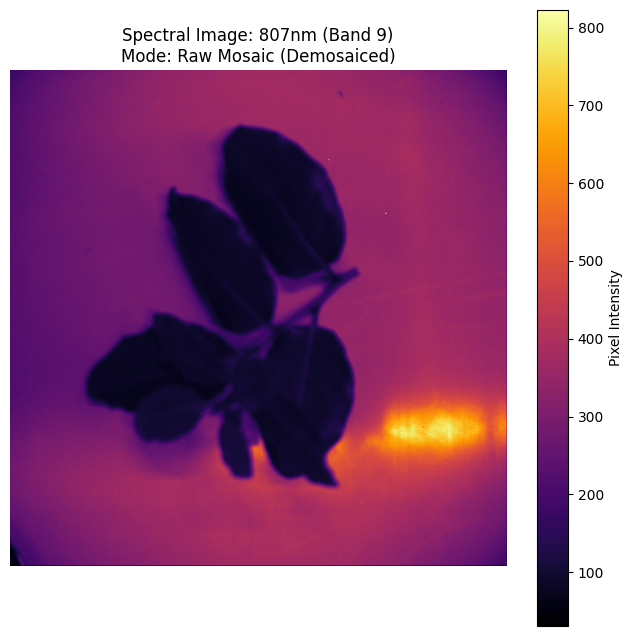

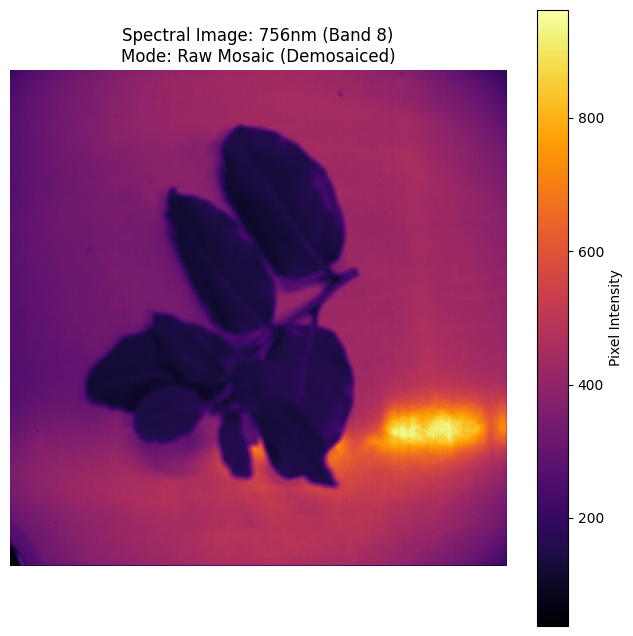

In [28]:
# Example 1: Show band by Index (0 = 410nm)
show_spectral_channel("C:/CROPSENSE/CROPSENSE_DATA/2025-12-10/test/Spectral/test_20251201_153000_830_00000000_raw.tiff", channel_index=8)

# Example 2: Show band by Wavelength (e.g., Red Edge 756nm)
show_spectral_channel("C:/CROPSENSE/CROPSENSE_DATA/2025-12-10/test/Spectral/test_20251201_153000_830_00000000_raw.tiff", wavelength=756)

📊 Statistics for thermal_presample_00-08-09-074-thermo.tiff:
   🔹 Min: 19451.00
   🔸 Max: 26366.00
   sz Mean: 22738.63


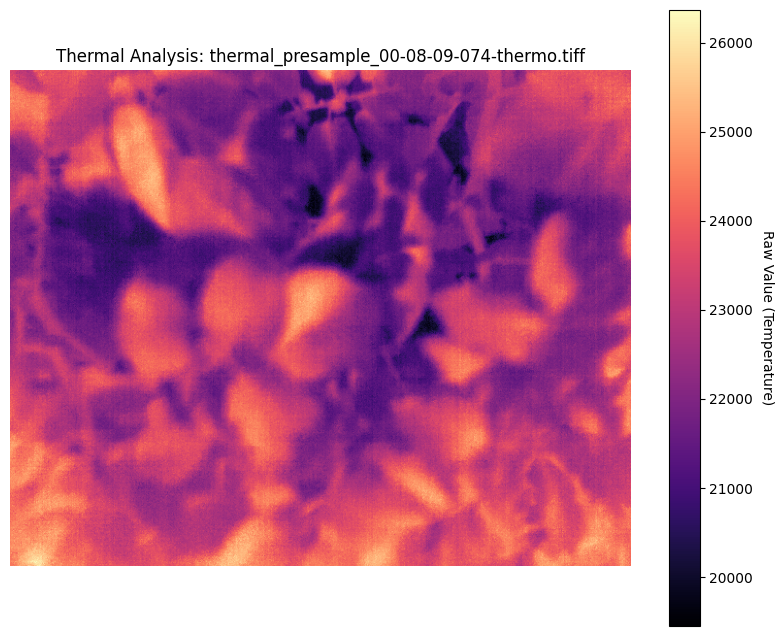

📊 Statistics for thermal_presample_00-08-09-074-cwsi.tiff:
   🔹 Min: 1904.00
   🔸 Max: 5070.00
   sz Mean: 3409.06


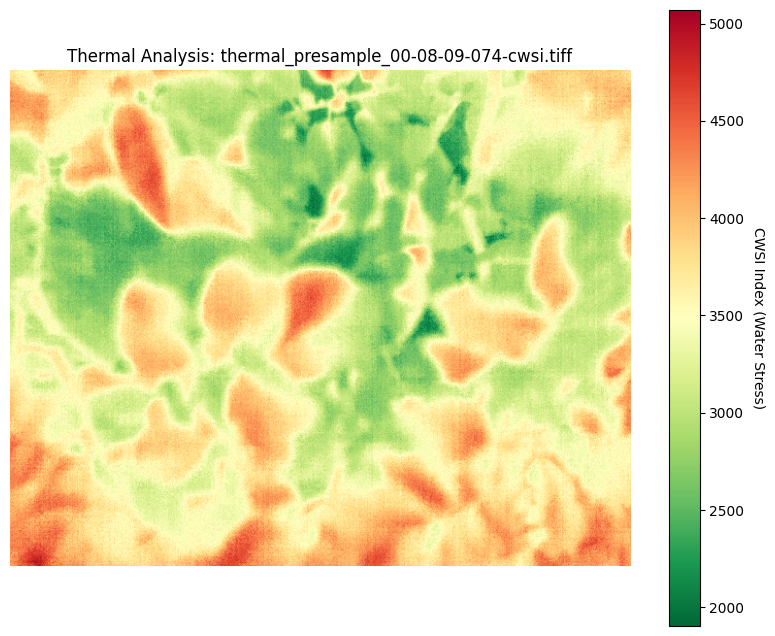

In [29]:
# --- EXAMPLE: Plot a thermic image file ---
# This will show the temperature and the water stress.
show_thermal_image("C:/CROPSENSE/CROPSENSE_DATA/2025-12-10/PreSample/Thermal/Thermal_PreSample_00-08-09-074-thermo.tiff")
show_thermal_image("C:/CROPSENSE/CROPSENSE_DATA/2025-12-10/PreSample/Thermal/Thermal_PreSample_00-08-09-074-cwsi.tiff")

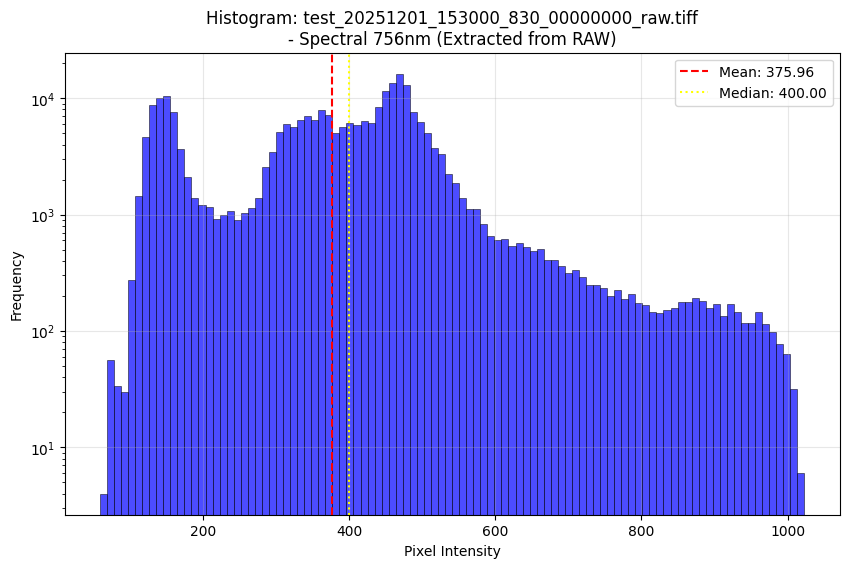

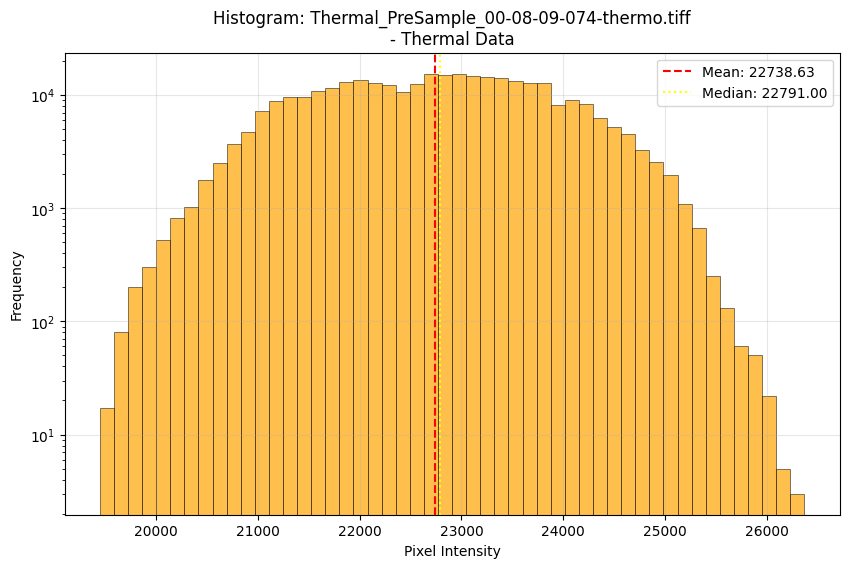

In [30]:
# --- EXAMPLE 1: Check the "Red Edge" band (Index 7) of a multispectral file ---
# This helps you see if the specific band used for NDVI is well exposed.
spectral_file = "C:/CROPSENSE/CROPSENSE_DATA/2025-12-10/test/Spectral/test_20251201_153000_830_00000000_raw.tiff"
plot_image_histogram(spectral_file, band_index=7, bins=100, log_scale=True)

# --- EXAMPLE 2: Check a Thermal Temperature Map ---
# This shows the distribution of temperatures (e.g., most pixels are around 22°C).
thermal_file = "C:/CROPSENSE/CROPSENSE_DATA/2025-12-10/PreSample/Thermal/Thermal_PreSample_00-08-09-074-thermo.tiff"
plot_image_histogram(thermal_file, bins=50, log_scale=True)

O

⚠️ Raw 2D Image detected ((2048, 2048)). Cannot separate bands without demosaicing.
📊 Plotting Global Raw Histogram instead.


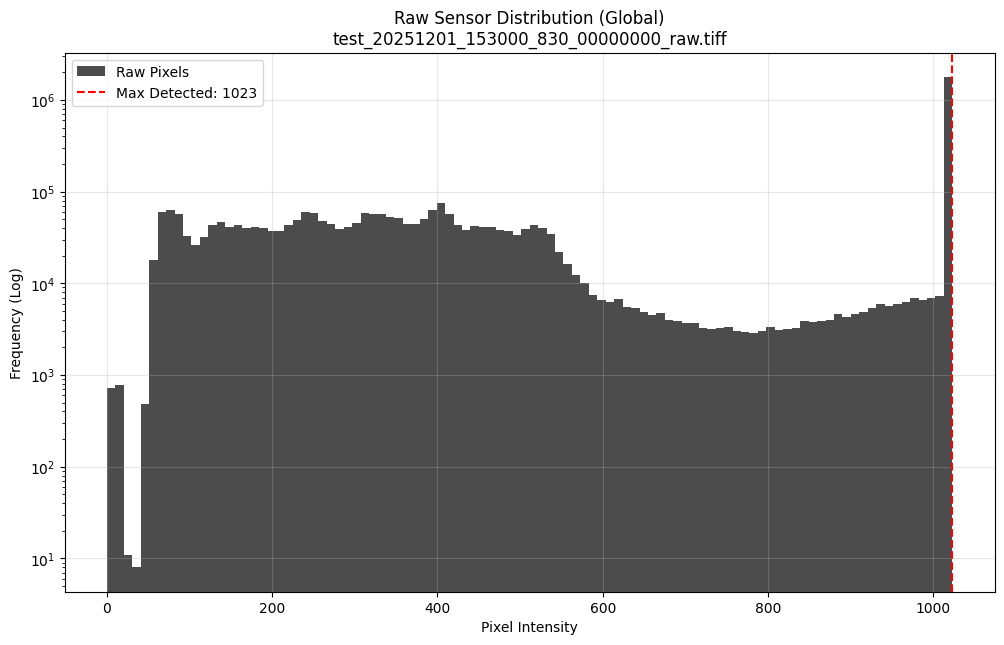

⚠️ Raw 2D Image detected ((2048, 2048)). Cannot separate bands without demosaicing.
📊 Plotting Global Raw Histogram instead.


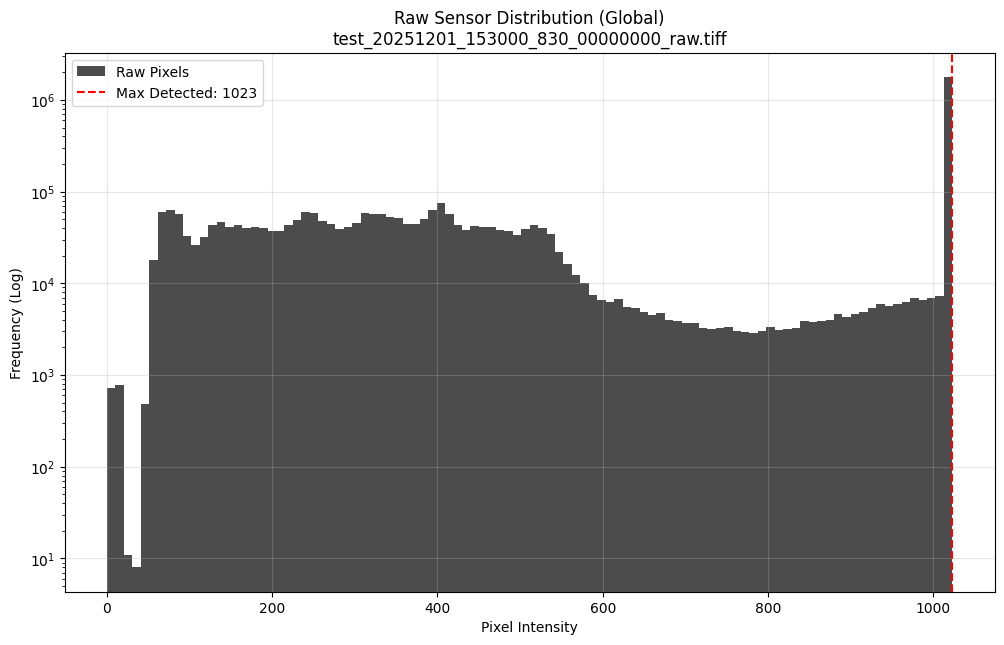

In [31]:

# --- EXAMPLE 1: Overlay Mode (Recommended) ---
# Draws 10 colored lines. Perfect to see if ONE specific band is dead or saturated.
plot_full_spectral_histogram("C:/CROPSENSE/CROPSENSE_DATA/2025-12-10/test/Spectral/test_20251201_153000_830_00000000_raw.tiff", mode='overlay', log_scale=True)

# --- EXAMPLE 2: Global Mode ---
# Aggregates everything. Good to see the overall brightness of the image.
plot_full_spectral_histogram("C:/CROPSENSE/CROPSENSE_DATA/2025-12-10/test/Spectral/test_20251201_153000_830_00000000_raw.tiff", mode='global', log_scale=True)

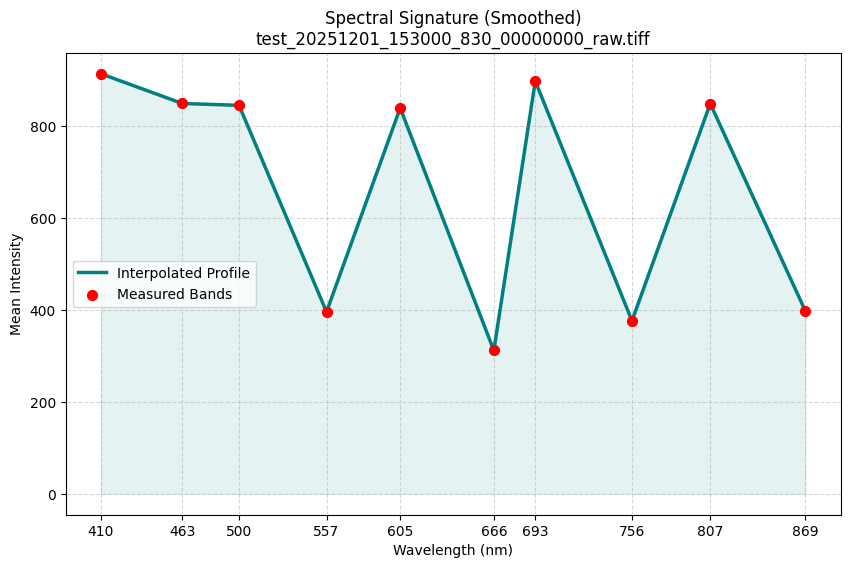

In [41]:
plot_spectral_profile("C:/CROPSENSE/CROPSENSE_DATA/2025-12-10/test/Spectral/test_20251201_153000_830_00000000_raw.tiff", smooth=False)

In [33]:
# --- EXAMPLE: Export data to a CSV file ---
# This will create a file named 'Analysis_P01.csv' in your current folder.
# You can then open this file in Excel to make your own custom graphs.
df = export_histogram_to_csv("C:/CROPSENSE/CROPSENSE_DATA/2025-12-10/test/Spectral/test_20251201_153000_830_00000000_raw.tiff", output_csv="Analysis_P01.csv")

# Optional: Print the first few rows to verify
print(df.head())

✅ Histogram data exported to: Analysis_P01.csv
   Bin_Start  Pixel_Count
0   0.000000           66
1   3.996094          267
2   7.992188          554
3  11.988281          500
4  15.984375          107
